# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [ ]:
! ls drive/MyDrive/Files/credit_risk_dataset.csv.csv

ls: cannot access 'drive/MyDrive/Files/credit_risk_dataset.csv.csv': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/credit_risk_dataset.csv')

In [ ]:
# 2. Виведення розміру датасету
print(f"Розмір датасету: {df.shape[0]} рядків та {df.shape[1]} стовпців\n")

Розмір датасету: 32581 рядків та 12 стовпців



In [ ]:
# 3. Перші 5 рядків
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# 4. Загальна інформація про дані

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
# 5. Розподіл цільової змінної
print("\nРозподіл цільової змінної (loan_status):")
class_counts = df['loan_status'].value_counts(normalize=True) * 100
print(class_counts)


Розподіл цільової змінної (loan_status):
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Обробка пропущених значень
missing_pct = df.isnull().mean() * 100
print("Відсоток пропусків:\n", missing_pct[missing_pct > 0])


Відсоток пропусків:
 person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64


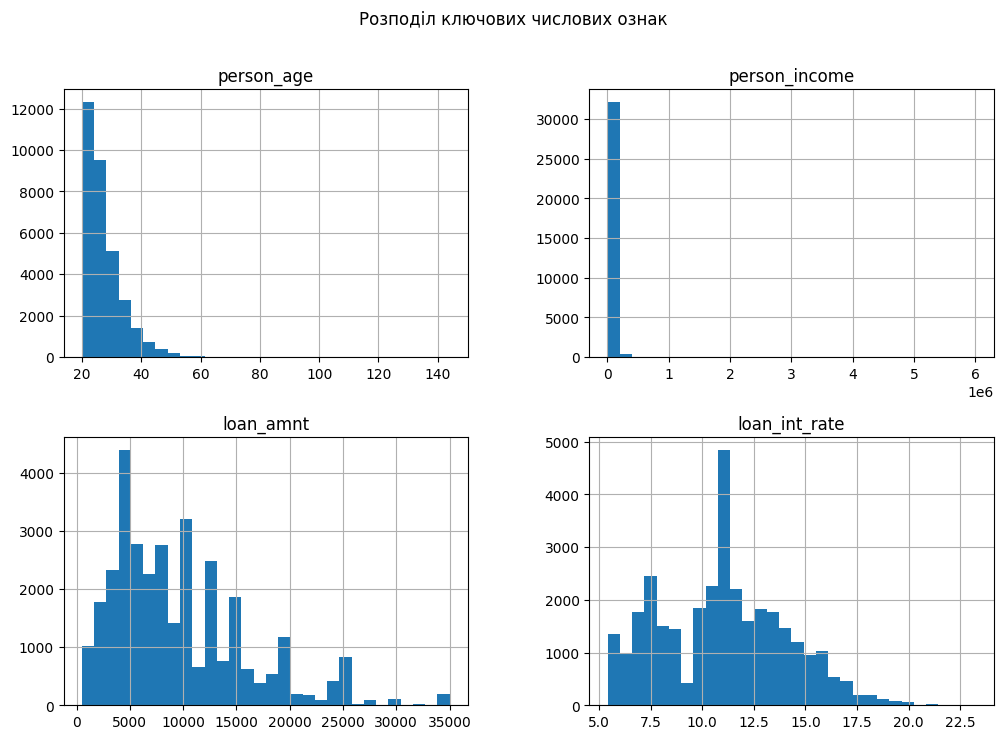

In [ ]:
# Заповнюємо числові медіаною, категоріальні - модою
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# 2. Аналіз розподілу числових змінних
df[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].hist(bins=30, figsize=(12, 8))
plt.suptitle("Розподіл ключових числових ознак")
plt.show()


In [ ]:
# 3. Обробка викидів в person_income (Метод IQR)
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фільтруємо датасет
df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()
print(f"Видалено рядків з аномальним доходом: {len(df) - len(df_clean)}")

# Додатково: прибираємо аномальний вік (наприклад, > 100 років)
df_clean = df_clean[df_clean['person_age'] < 100]

Видалено рядків з аномальним доходом: 1484


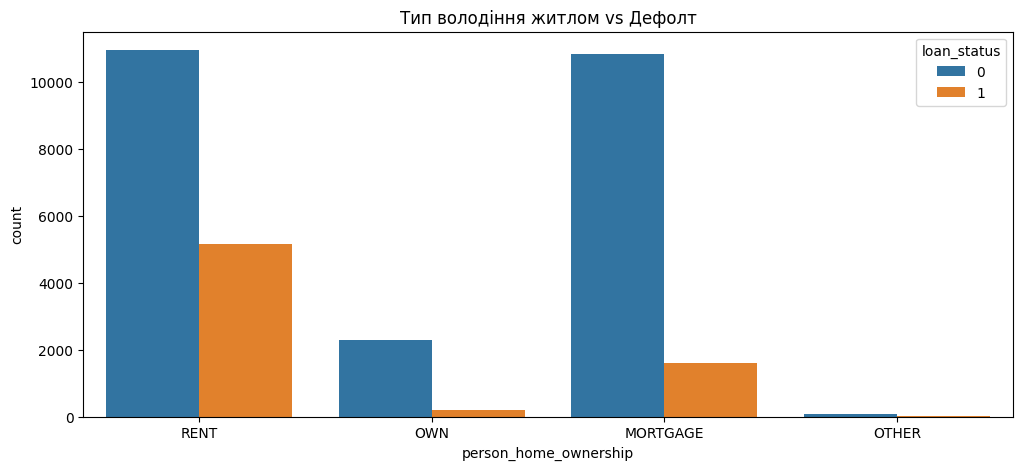


Частота кредитних рейтингів (loan_grade):
loan_grade
A    10343
B     9922
C     6191
D     3459
E      899
F      221
G       60
Name: count, dtype: int64


In [ ]:
# 4-5. Аналіз категоріальних змінних та взаємозв'язку
plt.figure(figsize=(12, 5))
sns.countplot(data=df_clean, x='person_home_ownership', hue='loan_status')
plt.title("Тип володіння житлом vs Дефолт")
plt.show()

# Частота значень для кредитних рейтингів
print("\nЧастота кредитних рейтингів (loan_grade):")
print(df_clean['loan_grade'].value_counts())



---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



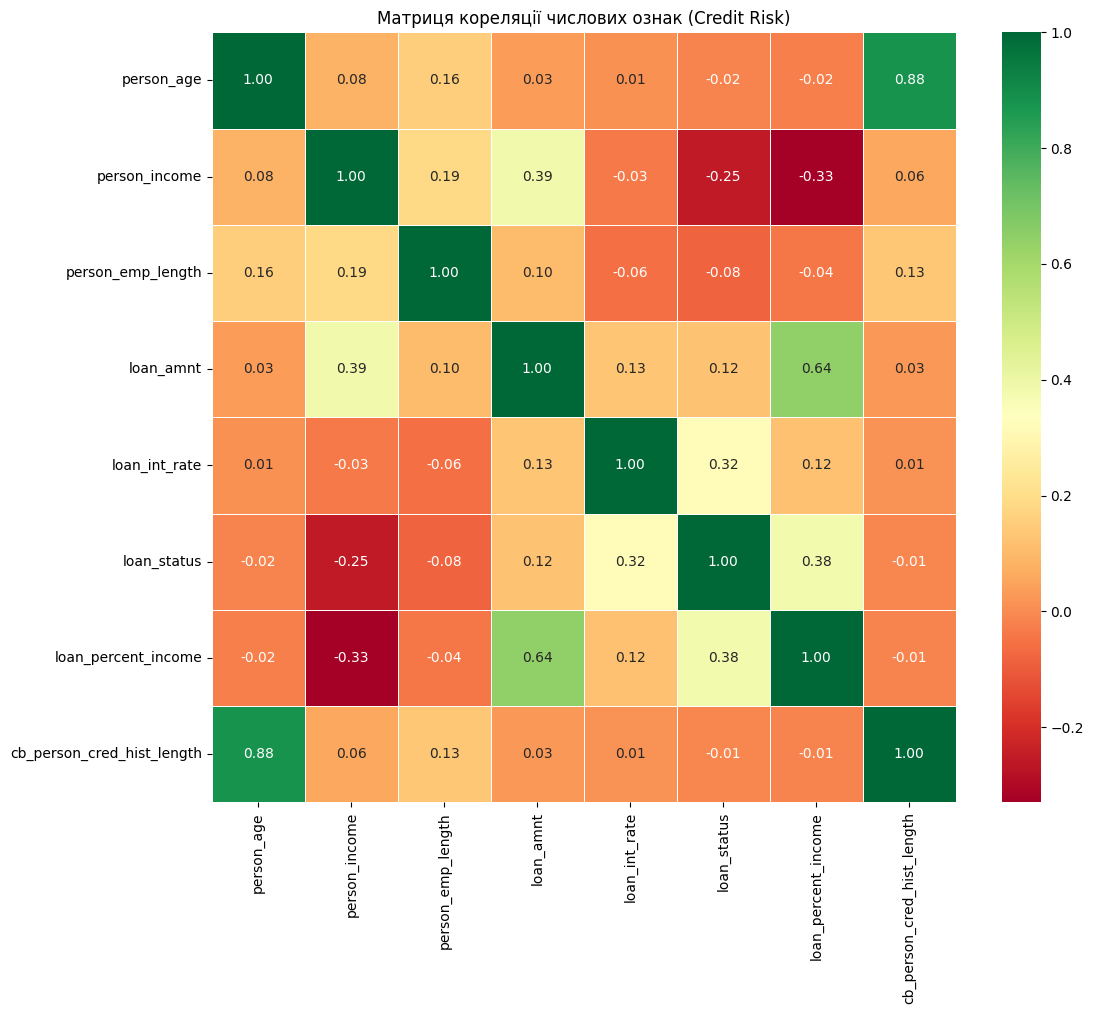

In [ ]:
# 1. Матриця кореляцій для числових змінних
# Використовуємо очищений датасет df_clean
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляції числових ознак (Credit Risk)')
plt.show()


In [ ]:
# 2. Закодуйте категоріальні змінні
# Використовуємо One-Hot Encoding для номінальних змінних
# та Label Encoding/Mapping для порядкових (як-от loan_grade)

# Порядкове кодування для loan_grade (A-G: 0-6)
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df_clean['loan_grade'] = df_clean['loan_grade'].map(grade_map)

# One-Hot Encoding для решти текстових колонок
categorical_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
df_final = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 3. Вибір фінального набору ознак
# Виключаємо цільову змінну 'loan_status' з ознак
X = df_final.drop(columns=['loan_status'])
y = df_final['loan_status']

print(f"Фінальна кількість ознак для моделі: {X.shape[1]}")
print("Список ознак:", X.columns.tolist())


Фінальна кількість ознак для моделі: 17
Список ознак: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_Y']



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



In [ ]:
# 1. Надійне заповнення пропусків
# Обов'язково заповнюємо пропуски В УСЬОМУ датасеті перед кодуванням
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        # Заповнюємо числові медіаною
        df[col] = df[col].fillna(df[col].median())
    else:
        # Заповнюємо категоріальні модою (найчастішим значенням)
        df[col] = df[col].fillna(df[col].mode()[0])

# 2. Очистка від викидів (як у Завданні 2)
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['person_income'] >= (Q1 - 1.5 * IQR)) &
              (df['person_income'] <= (Q3 + 1.5 * IQR))].copy()

# 3. Кодування (Завдання 3)
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df_clean['loan_grade'] = df_clean['loan_grade'].map(grade_map)

categorical_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
df_final = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# ПЕРЕВІРКА: чи залишилися NaN?
if df_final.isnull().values.any():
    print("Увага! NaN все ще є. Видаляємо залишкові пропуски...")
    df_final = df_final.dropna()

# 4. Повторне розділення та навчання (Завдання 4)
X = df_final.drop(columns=['loan_status'])
y = df_final['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)


print("Модель успішно навчена!")
print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")


Модель успішно навчена!
Розмір навчальної вибірки: (24877, 17)
Розмір тестової вибірки: (6220, 17)



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


<Figure size 600x500 with 0 Axes>

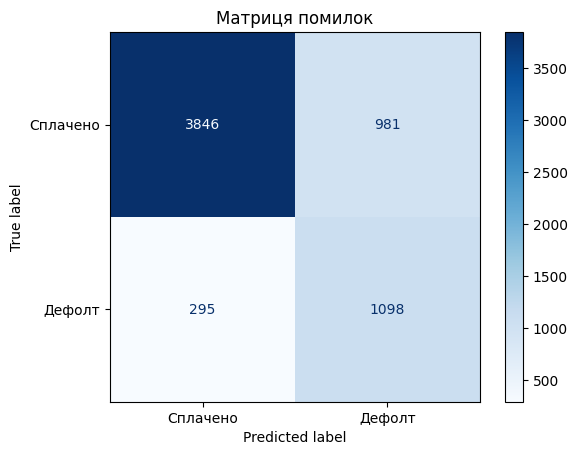

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc)

# 0. Створення прогнозів
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено', 'Дефолт'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Матриця помилок")
plt.show()


In [ ]:
# 2. Основні метрики
print("\n--- Звіт про класифікацію ---")
print(classification_report(y_test, y_pred))



--- Звіт про класифікацію ---
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4827
           1       0.53      0.79      0.63      1393

    accuracy                           0.79      6220
   macro avg       0.73      0.79      0.75      6220
weighted avg       0.84      0.79      0.81      6220



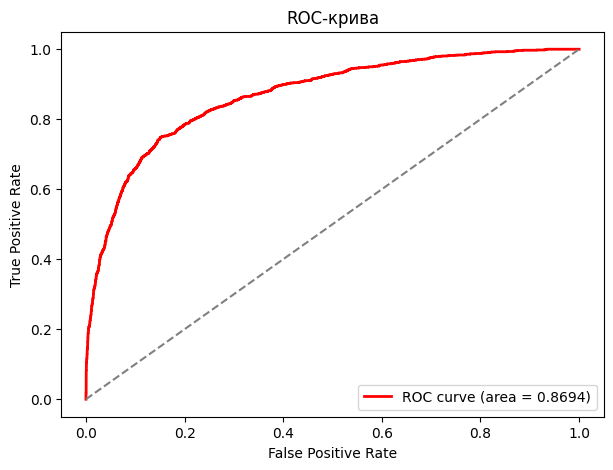

In [ ]:
# 3. ROC-крива та AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-крива')
plt.legend(loc="lower right")
plt.show()


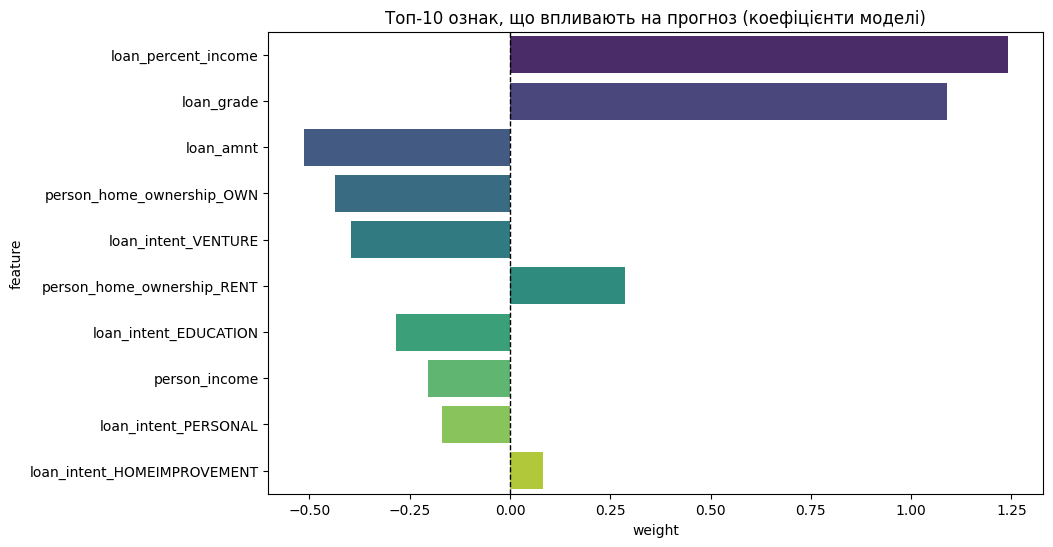

In [ ]:
# 4. Аналіз важливості ознак

importance = pd.DataFrame({
    'feature': X.columns,
    'weight': model.coef_[0]
}).sort_values(by='weight', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
# Додаємо hue='feature' та legend=False, щоб прибрати FutureWarning
sns.barplot(
    data=importance.head(10),
    x='weight',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.title('Топ-10 ознак, що впливають на прогноз (коефіцієнти моделі)')
plt.axvline(x=0, color='black', lw=1, ls='--') # лінія нуля для зручності
plt.show()



▶**Висновок про якість моделі:**

*Висока якість:*

Модель має відмінний показник AUC = 0.8694, що підтверджує її здатність точно розрізняти ризикових клієнтів.

*Ефективність:*

Завдяки Recall = 0.79, банк виявляє майже 80% потенційних дефолтів, що значно мінімізує фінансові втрати.

▶**Найвпливовіші ознаки:**

*Головні ризики:*

 Найбільше імовірність дефолту підвищують висока частка кредиту відносно доходу (loan_percent_income) та поганий кредитний рейтинг (loan_grade). Оренда житла (RENT) також додає ризику.

*Чинники надійності:*

 Найбільше знижують ризик наявність власного житла (OWN), високий річний дохід та мета кредиту на освіту чи бізнес.
Підсумок: Модель логічно інтерпретує дані та готова до використання в системі кредитного скорингу.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



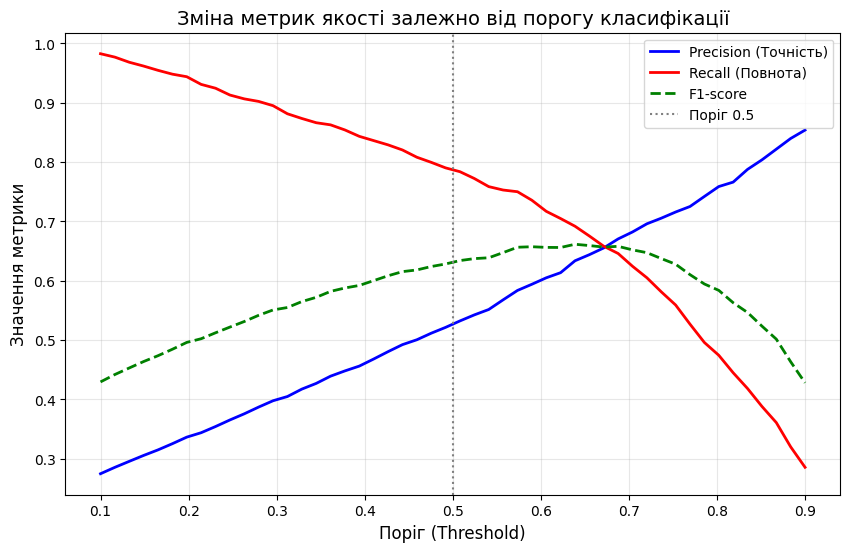

Поріг   | Precision  | Recall     | F1-score  
---------------------------------------------
0.20    | 0.337      | 0.944      | 0.496     
0.35    | 0.427      | 0.866      | 0.572     
0.50    | 0.522      | 0.790      | 0.628     
0.65    | 0.644      | 0.676      | 0.659     
0.80    | 0.759      | 0.475      | 0.584     

Математично оптимальний поріг (max F1): 0.64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Отримання ймовірностей (використовуємо вашу навчену модель)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Списки для збереження значень метрик
thresholds = np.linspace(0.1, 0.9, 50)
precisions = []
recalls = []
f1_scores = []

# Розрахунок метрик для кожного порогу
for t in thresholds:
    y_p = (y_probs >= t).astype(int)
    precisions.append(precision_score(y_test, y_p, zero_division=0))
    recalls.append(recall_score(y_test, y_p))
    f1_scores.append(f1_score(y_test, y_p))

# 2. Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision (Точність)', color='blue', lw=2)
plt.plot(thresholds, recalls, label='Recall (Повнота)', color='red', lw=2)
plt.plot(thresholds, f1_scores, label='F1-score', color='green', linestyle='--', lw=2)

# Додаємо вертикальну лінію на стандартному порозі 0.5
plt.axvline(x=0.5, color='gray', linestyle=':', label='Поріг 0.5')

plt.title('Зміна метрик якості залежно від порогу класифікації', fontsize=14)
plt.xlabel('Поріг (Threshold)', fontsize=12)
plt.ylabel('Значення метрики', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Вивід 5 конкретних порогів для звіту (згідно з умовою)
print(f"{'Поріг':<7} | {'Precision':<10} | {'Recall':<10} | {'F1-score':<10}")
print("-" * 45)
report_thresholds = [0.2, 0.35, 0.5, 0.65, 0.8]

for t in report_thresholds:
    # Знаходимо найближчий індекс до обраного порогу
    idx = np.argmin(np.abs(thresholds - t))
    print(f"{t:<7.2f} | {precisions[idx]:<10.3f} | {recalls[idx]:<10.3f} | {f1_scores[idx]:<10.3f}")

# 4. Знаходження математично оптимального порогу (максимум F1)
opt_idx = np.argmax(f1_scores)
print(f"\nМатематично оптимальний поріг (max F1): {thresholds[opt_idx]:.2f}")



---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Використовуємо оптимальний поріг, знайдений у Завданні 6 (наприклад, 0.4)
best_threshold = 0.4

# Словник для збереження моделей
models = {
    "Logistic Regression": model, # Ваша вже навчена модель
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

results = []

print(f"{'Модель':<20} | {'F1-score':<10} | {'ROC-AUC':<10}")
print("-" * 45)

for name, clf in models.items():
    # Навчаємо нові моделі (крім логістичної, яка вже є)
    if name != "Logistic Regression":
        clf.fit(X_train_scaled, y_train)

    # Отримуємо ймовірності
    y_probs = clf.predict_proba(X_test_scaled)[:, 1]

    # Застосовуємо поріг для прогнозів
    y_pred_custom = (y_probs >= best_threshold).astype(int)

    # Рахуємо метрики
    f1 = f1_score(y_test, y_pred_custom)
    auc = roc_auc_score(y_test, y_probs)

    results.append({"Model": name, "F1": f1, "AUC": auc})
    print(f"{name:<20} | {f1:<10.3f} | {auc:<10.3f}")


Модель               | F1-score   | ROC-AUC   
---------------------------------------------
Logistic Regression  | 0.596      | 0.869     
Decision Tree        | 0.752      | 0.911     
Random Forest        | 0.819      | 0.932     
